=== source
codebase/plotting/notebooks/region-overlap-stats/errors-over-stitched.ipynb
===
Save folder
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/region-overlap-stats/err-by-patched
Save folder
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/region-overlap-stats/err-by-patched


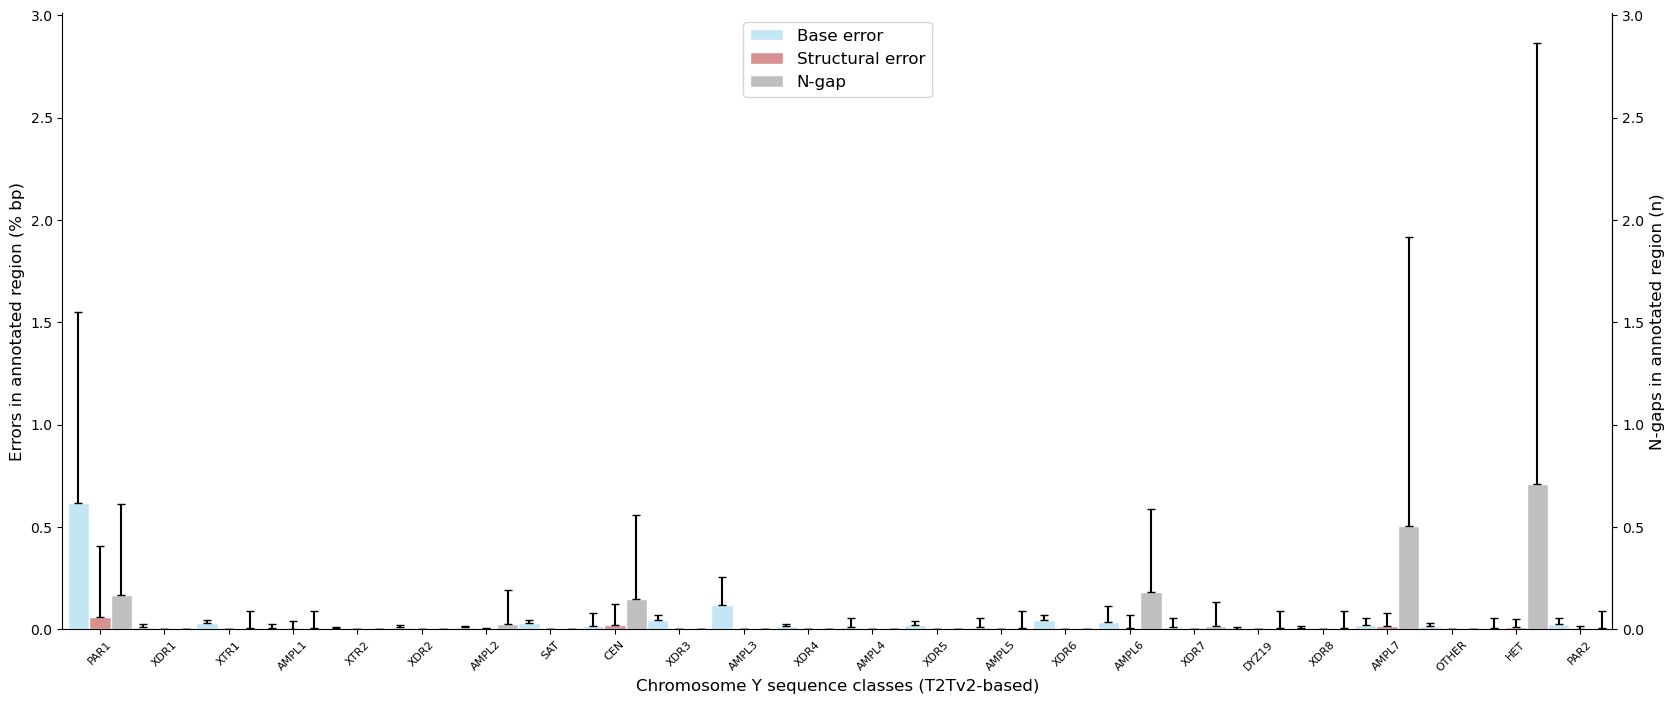

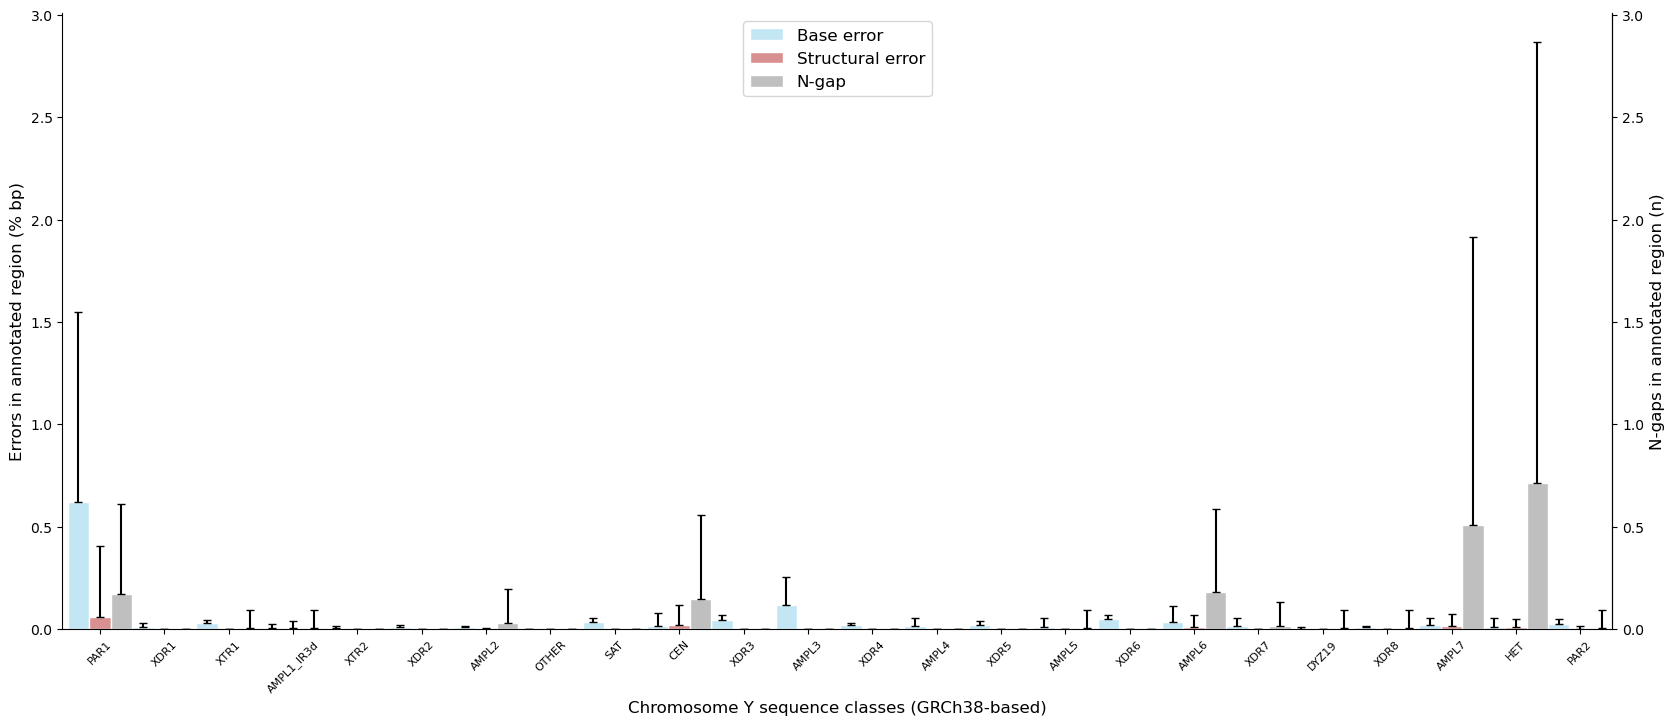

In [7]:
import pathlib as pl

# adapt relative path until it loads
cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
TABLE_ROOT = CONFIG["table_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# below: NB-specific code

PAPER_CONTENT = True
if PAPER_CONTENT:
    print("=== source")
    print(NB_REL_PATH)
    print("===")

import json
import collections as col
import dataclasses as dcl

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mplcol
import matplotlib.lines as mpllin
import matplotlib.patches as mplpatch

@dcl.dataclass
class IssueColors:
    NGAP = mplcol.to_rgba("grey", alpha=0.5)
    UNASSIGNED = mplcol.to_rgba("orange", alpha=0.5)
    ERRSTRUCT = mplcol.to_rgba("firebrick", alpha=0.5)
    ERRBASE = mplcol.to_rgba("skyblue", alpha=0.5)
    
    def get_color_labels(self):
        labels = [
            "N-gap",
            "Unassigned",
            "Structural error",
            "Base error",
            
        ]
        return labels

    def get_legend_label(self, issue):
        lut = dict((k,v) for k, v in zip(self.get_issue_labels(), self.get_color_labels()))
        return lut[issue]

    def get_issue_labels(self):
        labels = [
            "NGAP",
            "UNASSIGNED",
            "ERRSTRUCT",
            "ERRBASE",
        ]
        return labels


COLORMAP = IssueColors()


def define_label_order(ref):

    umbrella_file = sorted(DATA_ROOT.joinpath(
        f"wf-data/region-labels/umbrellas/{ref}"
    ).glob(f"{ref}.*.json"))[0]
    with open(umbrella_file) as dump:
        umbrellas = json.load(dump)
    label_order = []
    for k in sorted(umbrellas.keys()):
        uni = umbrellas[k]["unified"]
        if uni in ["other1", "other2"]:
            uni = "OTHER"
        if uni in label_order:
            continue
        label_order.append(uni)
    #label_order = ["TELO"] + label_order
    return label_order


def read_sample_seq_class_file(file_path, label_order, merged_stats, merge_telomere=False, only_main=True):
    
    df = pd.read_csv(file_path, header=0, sep="\t")
    df.rename({"#seq": "seq"}, axis=1, inplace=True) 
    df["length"] = df["end"] - df["start"]
    if only_main:
        df = df.loc[df["seq"].str.endswith("_chrY"), :].copy()
    if merge_telomere:
        df["label"] = df["label"].replace({"TELOp": "PAR1", "TELOq": "PAR2"}, inplace=False)
        df["assign_label"] = df["assign_label"].replace({"TELOp": "PAR1", "TELOq": "PAR2"}, inplace=False)
        df["assign_group"] = df["assign_group"].replace({"TEL": "PAR"}, inplace=False)

    agg = df.groupby(["label", "assign_label"]).agg(
        longest_region=pd.NamedAgg(column="length", aggfunc="max"),
        length_total=pd.NamedAgg(column="length", aggfunc="sum"),
        regions_n=pd.NamedAgg(column="length", aggfunc="size"),
        seq_length=pd.NamedAgg(column="end", aggfunc="max")
    )
    issues = [l for l in COLORMAP.get_issue_labels() if l != "UNASSIGNED"]

    for label in label_order:
        for issue in issues:
            if issue == "NGAP":
                select_column = "regions_n"
            else:
                select_column = "length_total"
            try:
                region_length = agg.loc[(label, label), "length_total"]
            except KeyError:
                # can happen for incomplete assemblies lacking, e.g., PAR2
                region_length = 1
                # avoid div by zero below
            try:
                issue_value = agg.loc[(issue, label), select_column]
            except KeyError:
                issue_value = 0
            if issue == "NGAP":
                error_value = issue_value
            else:
                error_value = round(issue_value/region_length*100, 3)
            merged_stats[(label, issue)].append(error_value)
            
    return None


legend_elements = []

for other, legend_label in zip(COLORMAP.get_issue_labels(), COLORMAP.get_color_labels()):
    # skipping - see below
    if other == "UNASSIGNED":
        continue
    if other == "ERRBASE":
        continue
    color = getattr(COLORMAP, other)
    elem = mpllin.Line2D(
        [], [], color="white",
        markerfacecolor=color, markersize=10,
        marker="o", label=legend_label
    )
    legend_elements.append(elem)


# DATA_TABLE = DATA_ROOT.joinpath(
#     "wf-data/region-labels/stitched_final_isect/all-mrg.errors-stitched.tsv"
# ).resolve(strict=True)

# stats = pd.read_csv(DATA_TABLE, sep="\t", header=0, index_col=[0,1,2,3,4,5])

DATA_FILES_ROOT = DATA_ROOT.joinpath(
    "wf-data/region-labels/final_annot/2026-02_final-rev/patched"
)

refs = ["t2tv2", "hg38"]
ref_label = {
    "t2tv2": "T2Tv2",
    "hg38": "GRCh38"
}

for ref in refs:

    merged_stats = col.defaultdict(list)

    assert len(merged_stats) == 0
    
    #if ref == "hg38":
    #    continue
    label_order = define_label_order(ref)

    DATA_FILES = list(DATA_FILES_ROOT.joinpath(ref).glob("*.bed"))
    assert len(DATA_FILES) == 142

    for data_file in DATA_FILES:
        read_sample_seq_class_file(data_file, label_order, merged_stats, True, True)
    
    plot_data = col.defaultdict(list)
    for label in label_order:
        for issue, stat in [("ERRBASE", "pct"), ("ERRSTRUCT", "pct"), ("NGAP", "num")]:
            values = merged_stats[(label, issue)]
            assert len(values) == 142
            values = np.array(values)
            mean = np.mean(values)
            stddev = np.std(values)
            plot_data[issue].append((mean, stddev))

    fig, ax = plt.subplots(figsize=(20,8))

    for other, start_pos in [("ERRBASE", 1), ("ERRSTRUCT", 2)]:
        x_pos = np.arange(start_pos, len(label_order) * 3, step=3)[:len(label_order)]
        heights = [t[0] for t in plot_data[other]]
        errs = np.array([t[1] for t in plot_data[other]], dtype=float)
        errs = np.vstack((np.zeros_like(errs), errs))
        
        bars = ax.bar(
            x_pos,
            heights,
            width=1, align="center",
            label=COLORMAP.get_legend_label(other),
            facecolor=getattr(COLORMAP, other),
            edgecolor="white",
            yerr=errs,
            capsize=3
        )
        
    ax.set_xticks(x_pos)
    # 2026-05-11 / seems to be the desired labeling now...
    
    tick_labels = []
    for label in label_order:
        if label == "periCEN":
            tick_labels.append("SAT")
            continue
        if label == "CEN-DYZ3":
            tick_labels.append("CEN")
            continue
        tick_labels.append(label)
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=45)
    ax.set_ylabel("Errors in annotated region (% bp)", fontsize=12)

    y2_ax = ax.secondary_yaxis("right")

    last_x_pos = None
    for other, start_pos in [("NGAP", 3)]:
        x_pos = np.arange(start_pos, len(label_order) * 3+1, step=3)[:len(label_order)]
        last_x_pos = x_pos.max()
        heights = [t[0] for t in plot_data[other]]
        errs = np.array([t[1] for t in plot_data[other]], dtype=float)
        errs = np.vstack((np.zeros_like(errs), errs))
        
        bars = ax.bar(
            x_pos,
            heights,
            width=1, align="center",
            label=COLORMAP.get_legend_label(other),
            facecolor=getattr(COLORMAP, other),
            edgecolor="white",
            yerr=errs,
            capsize=3
        )
    y2_ax.set_ylabel("N-gaps in annotated region (n)", fontsize=12)
    
    ax.spines["top"].set_visible(False)

    ax.set_xlim(0.25, last_x_pos+0.5)
    ax.set_xlabel(f"Chromosome Y sequence classes ({ref_label[ref]}-based)", fontsize=12)
    ax.legend(loc="upper center", fontsize=12)

    out_file = PLOT_ROOT.joinpath("err-by-patched", f"fig-S3_pe_err-by-patched-regions.{ref}.png")
    if PAPER_CONTENT:
        print("Save folder")
        print(out_file.parent)
    out_file.parent.mkdir(exist_ok=True, parents=True)
    plt.savefig(out_file, bbox_inches="tight", dpi=150, transparent=None, facecolor="w")
    out_file = out_file.with_suffix(".pdf")
    plt.savefig(out_file, bbox_inches="tight", transparent=None, facecolor="w")